   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Missing Values
age         0
sex         0
bmi         0
children    

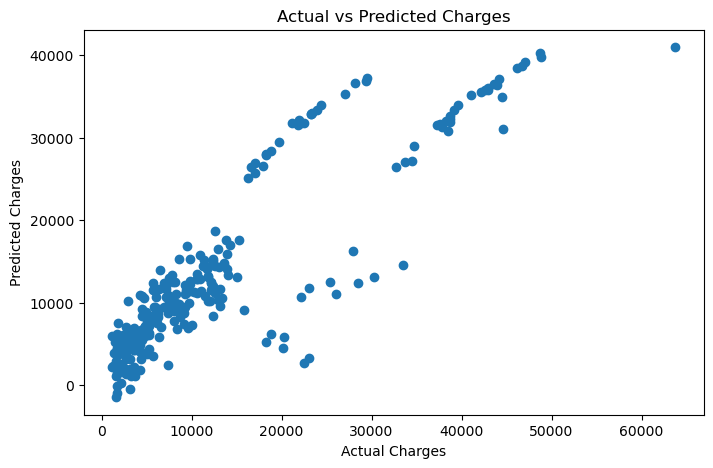


Predicted Insurance Charge: $1473.52


C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

insurance_data = pd.read_csv(r"C:\Users\ACER\Downloads\insurance.csv")

print(insurance_data.head())

print("\nDataset Information")
print(insurance_data.info())

print("\nMissing Values")
print(insurance_data.isnull().sum())

print("\nStatistical Summary")
print(insurance_data.describe())

label_encoder = LabelEncoder()

insurance_data['sex'] = label_encoder.fit_transform(insurance_data['sex'])
insurance_data['smoker'] = label_encoder.fit_transform(insurance_data['smoker'])
insurance_data['region'] = label_encoder.fit_transform(insurance_data['region'])

print("\nEncoded Dataset")
print(insurance_data.head())

x = insurance_data.drop('charges', axis=1)
y = insurance_data['charges']

x_train, x_test, y_train, y_test = train_test_split( x,y,test_size=0.2,random_state=42)

model = LinearRegression()

model.fit(x_train, y_train)

y_prediction = model.predict(x_test)

print("\nActual Values")
print(y_test.values[:10])

print("\nPredicted Values")
print(y_prediction[:10])

mse = mean_squared_error(y_test, y_prediction)
r2 = r2_score(y_test, y_prediction)

print("\nMean Squared Error:", mse)
print("R2 Score:", r2)

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_prediction)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.show()

sample_data = np.array([[25, 1, 22.5, 0, 0, 2]])

predicted_charge = model.predict(sample_data)[0]

print(f"\nPredicted Insurance Charge: ${predicted_charge:.2f}")